Dataset extracted successfully!
Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


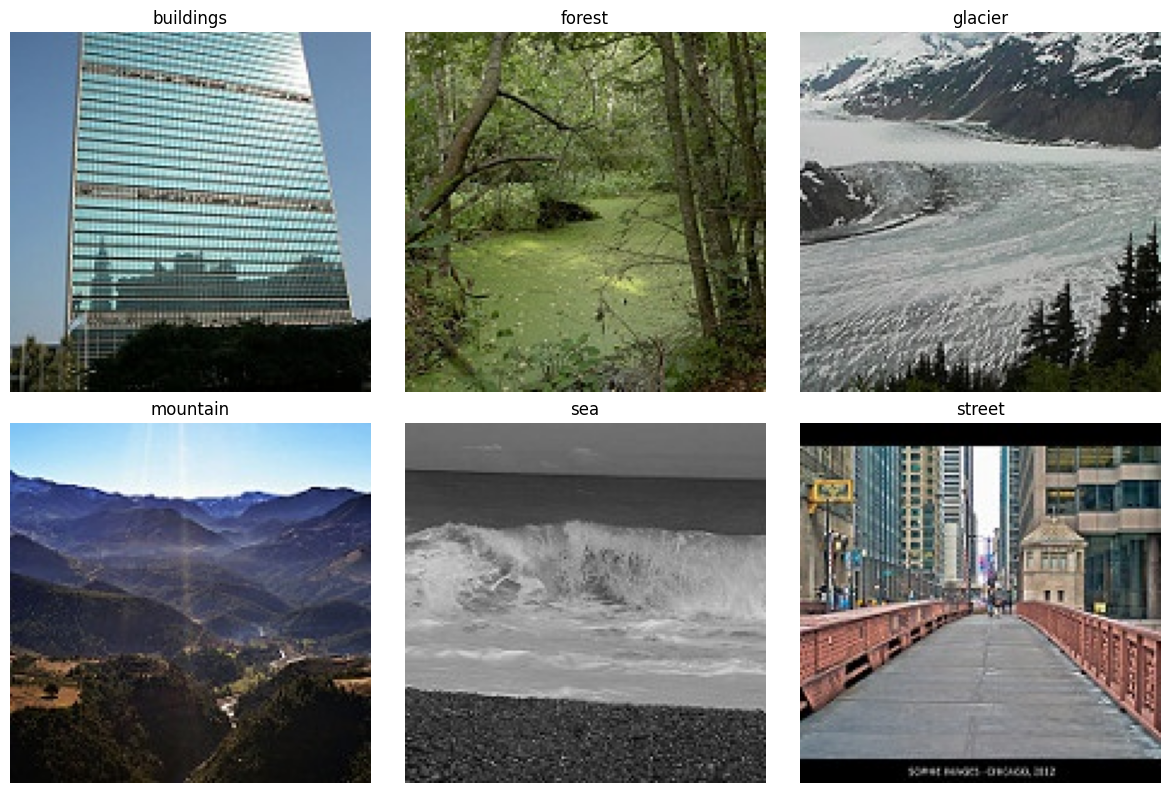

buildings : 2191 images
forest : 2271 images
glacier : 2404 images
mountain : 2512 images
sea : 2274 images
street : 2382 images


In [6]:
import zipfile
import os
import matplotlib.pyplot as plt
import cv2
import random

# UNZIP DATASET
# Путь к zip файлу
zip_path = r"C:\Users\Huawei\Downloads\archive (10).zip"

# Куда распаковать
extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

# Распаковка
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# SET TRAIN PATH
train_path = os.path.join(extract_path, "seg_train", "seg_train")
# CHECK CLASSE
classes = os.listdir(train_path)
print("Classes found:", classes)
# VISUALIZE SAMPLE IMAGES
plt.figure(figsize=(12, 8))
for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# DATA INSIGHT
# Количество изображений в каждом классе
for cls in classes:
    path = os.path.join(train_path, cls)
    print(cls, ":", len(os.listdir(path)), "images")

# COMMENT:
# This step:
# - loads dataset from ZIP file
# - extracts it
# - explores class structure
# - visualizes sample images
# - checks dataset balance 

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 67500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      34,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,693,382 (132.34 MB)

 Trainable params: 34,693,382 (132.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.6246 - loss: 0.9878 - val_accuracy: 0.7404 - val_loss: 0.7258
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 317s 698ms/step - accuracy: 0.7665 - loss: 0.6405 - val_accuracy: 0.7468 - val_loss: 0.6904
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 327s 712ms/step - accuracy: 0.8167 - loss: 0.4934 - val_accuracy: 0.7924 - val_loss: 0.5798
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 286s 724ms/step - accuracy: 0.8666 - loss: 0.3619 - val_accuracy: 0.8117 - val_loss: 0.5518
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 290s 735ms/step - accuracy: 0.9245 - loss: 0.2127 - val_accuracy: 0.8217 - val_loss: 0.6507
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 290s 733ms/step - accuracy: 0.9497 - loss: 0.1507 - val_accuracy: 0.8138 - val_loss: 0.7686
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 284s 720ms/step - accuracy: 0.9752 - loss: 0.0808 - val_accuracy: 0.7960 - val_loss: 0.9531
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 284s 718ms/step - accuracy: 0.9820 - lo

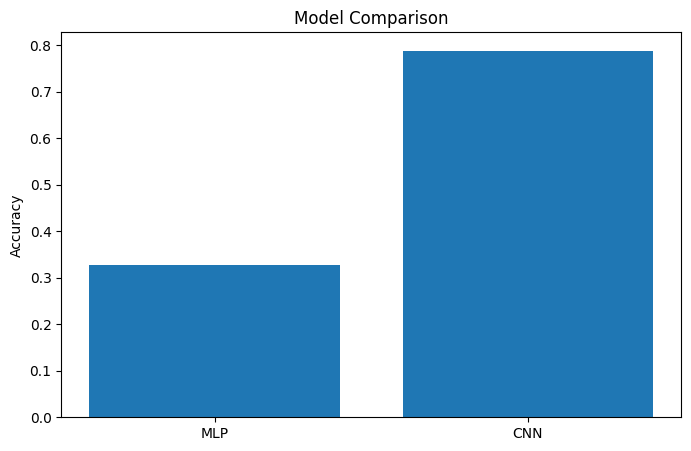

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

train_path = os.path.join(extract_path, "seg_train", "seg_train")
test_path = os.path.join(extract_path, "seg_test", "seg_test")

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

from tensorflow.keras import layers, models

def build_cnn():
    model = models.Sequential()

    model.add(layers.Input(shape=(150,150,3)))

    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def build_mlp():
    model = models.Sequential()

    # flatten image → vector
    model.add(layers.Flatten(input_shape=(150,150,3)))

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp()
mlp_model.summary()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

history_mlp = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator)
mlp_loss, mlp_acc = mlp_model.evaluate(test_generator)

print("CNN Accuracy:", cnn_acc)
print("MLP Accuracy:", mlp_acc)

plt.figure(figsize=(8,5))

plt.bar(["MLP", "CNN"], [mlp_acc, cnn_acc])

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()


Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           3,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,037,638 (72.62 MB)

 Trainable params: 19,037,190 (72.62 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/step - accuracy: 0.4550 - loss: 3.5298 - val_accuracy: 0.3438 - val_loss: 2.1332
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.5218 - loss: 1.2472 - val_accuracy: 0.5036 - val_loss: 1.3678
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.5465 - loss: 1.1905 - val_accuracy: 0.5357 - val_loss: 1.2072
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.5844 - loss: 1.0993 - val_accuracy: 0.4757 - val_loss: 1.7059
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.6059 - loss: 1.0668 - val_accuracy: 0.5842 - val_loss: 1.1172
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - accuracy: 0.6175 - loss: 1.0409 - val_accuracy: 0.6505 - val_loss: 1.0044
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.6231 - loss: 1.0158 - val_accuracy: 0.6191 - val_loss: 1.0012
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.6427 - loss: 0.9865 - val_accu

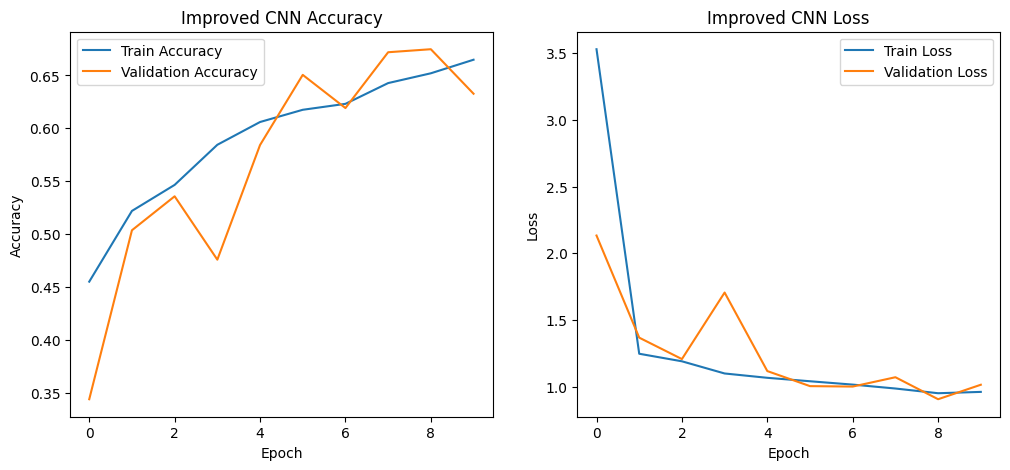

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


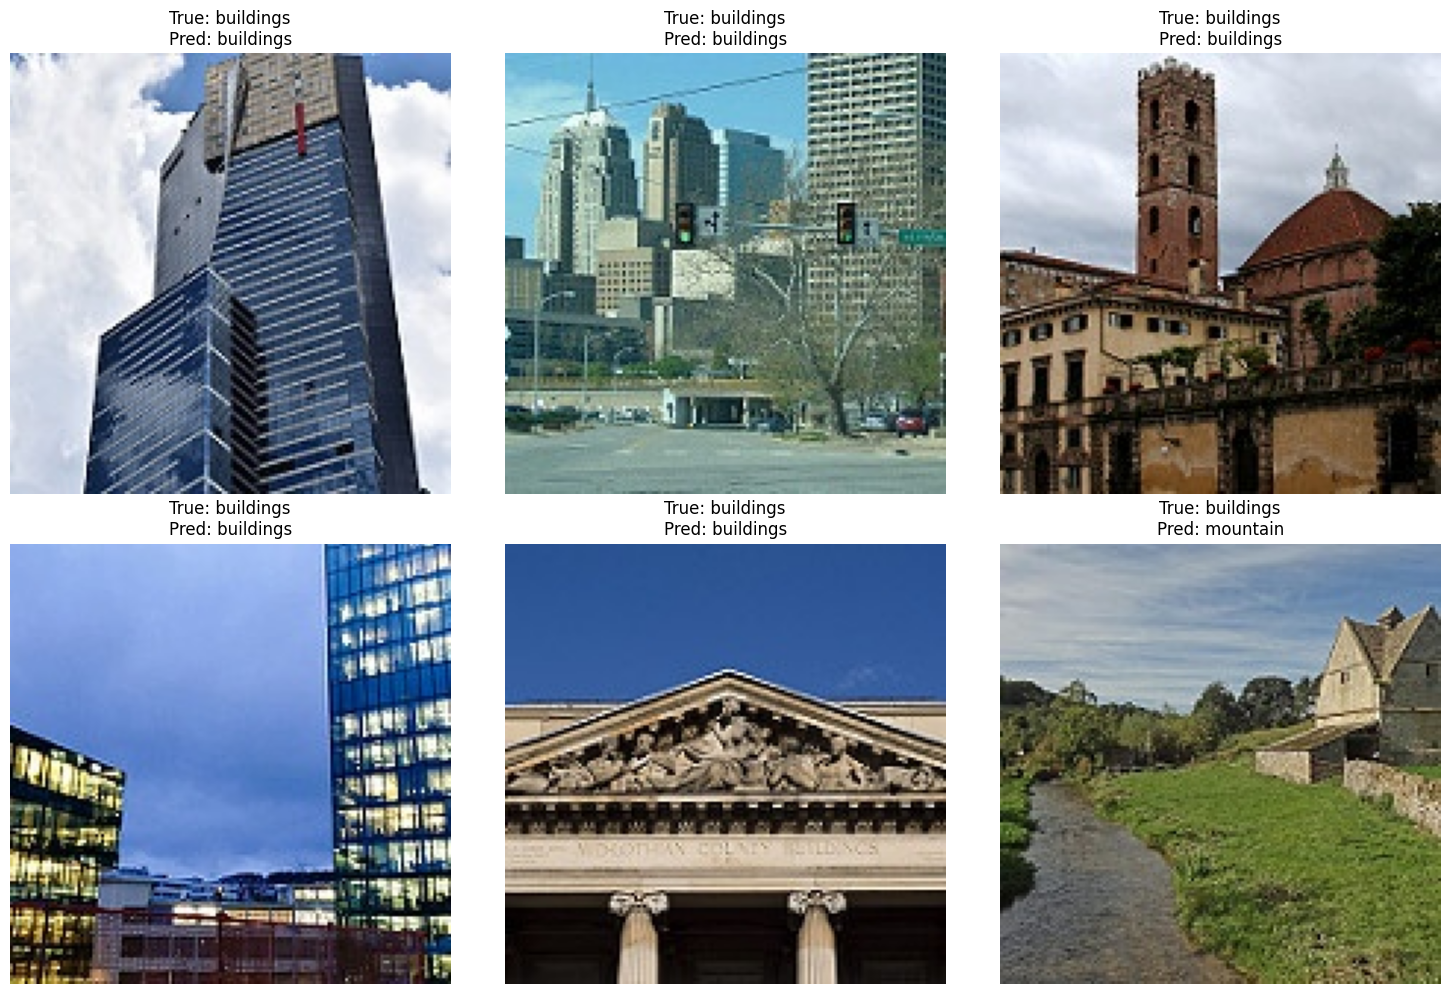

In [2]:
# IMPROVED CNN

# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import numpy as np
import os

# DATASET PATHS

extract_path = r"C:\Users\Huawei\Downloads\intel_dataset"

train_path = os.path.join(extract_path, "seg_train", "seg_train")
test_path = os.path.join(extract_path, "seg_test", "seg_test")

# IMAGE SETTINGS

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6

# DATA AUGMENTATION

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,

    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# DATA GENERATORS

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# IMPROVED CNN MODEL

def build_improved_cnn():

    model = models.Sequential()

    model.add(layers.Input(shape=(150,150,3)))

    # BLOCK 1
    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # BLOCK 2
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # BLOCK 3
    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2,2))

    # CLASSIFIER
    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # COMPILE
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# BUILD MODEL
improved_cnn = build_improved_cnn()

# MODEL SUMMARY
improved_cnn.summary()

# TRAIN MODEL

history_improved = improved_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# EVALUATE MODEL

test_loss, test_acc = improved_cnn.evaluate(test_generator)

print("\nImproved CNN Test Accuracy:", test_acc)
print("Improved CNN Test Loss:", test_loss)

# ACCURACY GRAPH

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')

plt.title("Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# LOSS GRAPH

plt.subplot(1,2,2)

plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')

plt.title("Improved CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# SAMPLE PREDICTIONS

class_names = list(train_generator.class_indices.keys())

images, labels = next(test_generator)

predictions = improved_cnn.predict(images)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    true_label = class_names[np.argmax(labels[i])]
    predicted_label = class_names[predicted_classes[i]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")

    plt.axis("off")

plt.tight_layout()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.6910 - loss: 0.8833

Final Test Accuracy: 0.6909999847412109
Final Test Loss: 0.8833442330360413
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step

Classification Report:

              precision    recall  f1-score   support

   buildings       0.57      0.81      0.67       437
      forest       0.95      0.92      0.94       474
     glacier       0.61      0.83      0.70       553
    mountain       0.66      0.67      0.66       525
         sea       0.79      0.09      0.16       510
      street       0.75      0.85      0.80       501

    accuracy                           0.69      3000
   macro avg       0.72      0.70      0.65      3000
weighted avg       0.72      0.69      0.65      3000



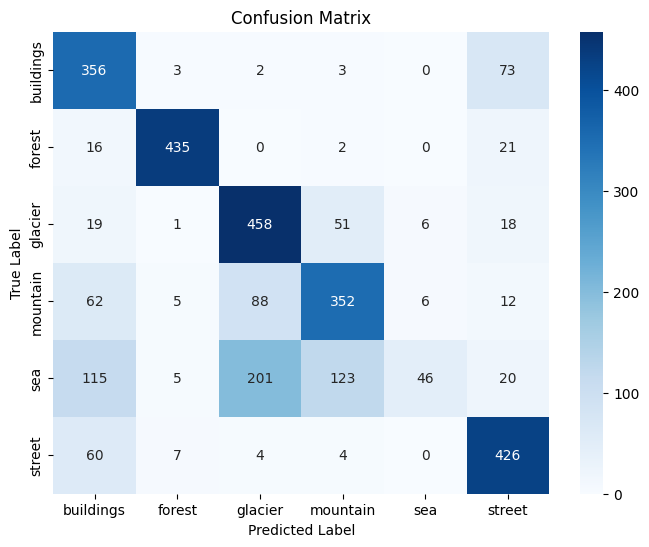

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


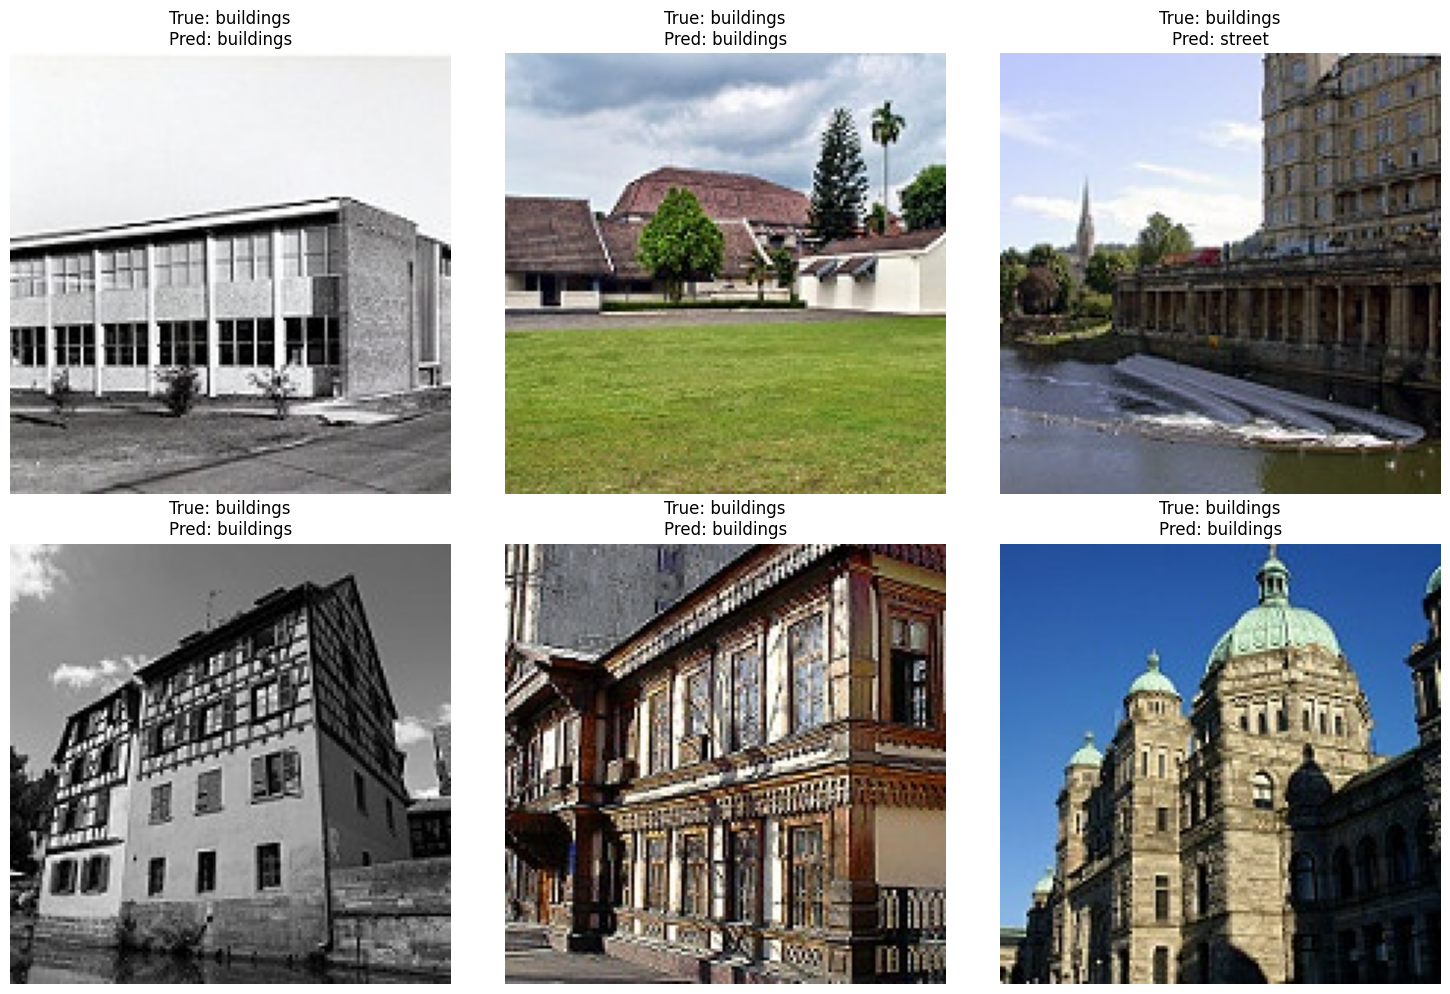


Model saved successfully!
File name: cnn_intel_final_model.keras

========== FINAL RESULTS ==========
Final Accuracy: 0.6910

Main Improvements:
- Data Augmentation
- Batch Normalization
- Dropout Regularization

Observed Challenges:
- Mountain vs Glacier confusion
- Longer training time
- Similar urban scene classes

Future Improvements:
- Transfer Learning (ResNet / VGG16 / EfficientNet)
- Early Stopping
- Learning Rate Scheduling
- More GPU training



In [3]:
# FINAL EVALUATION

# IMPORTS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import random
import os

# EVALUATE FINAL MODEL
test_loss, test_acc = improved_cnn.evaluate(test_generator)

print("\nFinal Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

# GENERATE PREDICTIONS
predictions = improved_cnn.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

# CONFUSION MATRIX
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# RANDOM SAMPLE PREDICTIONS
images, labels = next(test_generator)

preds = improved_cnn.predict(images)

predicted_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    true_label = class_names[np.argmax(labels[i])]
    predicted_label = class_names[predicted_labels[i]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# SAVE FINAL MODEL
improved_cnn.save("cnn_intel_final_model.keras")

print("\nModel saved successfully!")
print("File name: cnn_intel_final_model.keras")

# FINAL SUMMARY
print("\n========== FINAL RESULTS ==========")

print(f"Final Accuracy: {test_acc:.4f}")

print("""
Main Improvements:
- Data Augmentation
- Batch Normalization
- Dropout Regularization

Observed Challenges:
- Mountain vs Glacier confusion
- Longer training time
- Similar urban scene classes

Future Improvements:
- Transfer Learning (ResNet / VGG16 / EfficientNet)
- Early Stopping
- Learning Rate Scheduling
- More GPU training
""")


MODEL COMPARISON TABLE

          Model  Accuracy               Main Characteristics  \
0           MLP     0.650        Fully connected layers only   
1  Improved CNN     0.691  Convolution + BatchNorm + Dropout   

                               Advantages  \
0                         Simple and fast   
1  Better feature extraction and accuracy   

                             Limitations  
0  Cannot capture spatial image patterns  
1                   Longer training time  


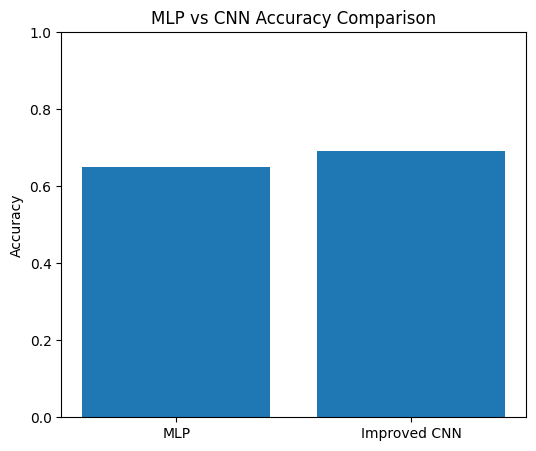

In [4]:
# MODEL COMPARISON TABLE

import pandas as pd

# Example results

mlp_accuracy = 0.65
cnn_accuracy = test_acc

comparison_data = {
    "Model": ["MLP", "Improved CNN"],
    "Accuracy": [mlp_accuracy, cnn_accuracy],
    "Main Characteristics": [
        "Fully connected layers only",
        "Convolution + BatchNorm + Dropout"
    ],
    "Advantages": [
        "Simple and fast",
        "Better feature extraction and accuracy"
    ],
    "Limitations": [
        "Cannot capture spatial image patterns",
        "Longer training time"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nMODEL COMPARISON TABLE\n")

print(comparison_df)

# VISUAL COMPARISON GRAPH

plt.figure(figsize=(6,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("MLP vs CNN Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()